In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
# import geopandas as gpd
import pandas as pd
import seaborn as sns
from scipy.stats import qmc
from ipywidgets import IntProgress
import math as math

# importeren van ewatercycle
import ewatercycle
import ewatercycle.models
import ewatercycle.forcing

from ewatercycle_discharge import DischargeLocal

shape_file_area = 7.629080e+03 # in km^2

In [8]:
basin_name = "boven_suriname"

historical_start_date = "2019-01-01"
historical_end_date = "2024-12-31"
future_start_data = "2027-01-01"
future_end_data = "2099-12-31"

shapefile = Path.home() / "BEP-Julian" / "BEP-Julian" / "Suriname_Model" / "boven_suriname.shp"

forcing_route_CMIP = Path.home() / "BEP-Julian" / "BEP-Julian" / "Forcing" / "CMIP"

Eigen_model = Path.home() / "BEP-Julian" / "BEP-Julian" / "Suriname_Model" / "discharge_bmi"
# model_path_HBV = Path.home() / "tmp" / "HBV_model" / "CMIP"
# model_path_HBV.mkdir(exist_ok=True)

# gdf = gpd.read_file("estreams_cb_FR003882.shp")
# gdf = gdf.to_crs(epsg=2154)
# gdf["area_km2"] = gdf.geometry.area / 1e6  
# basin_area = gdf["area_km2"].sum()

In [10]:
# Option one: Generate CMIP data
cmip_dataset =  {
   'project': 'CMIP6',
   'activity': 'ScenarioMIP',
   'exp': 'ssp245',              # veranderen per generatie CMIP data
   'mip': 'day',
   'dataset': 'MPI-ESM1-2-HR',
   'ensemble': 'r1i1p1f1',
   'institute': 'DKRZ',
   'grid': 'gn'
}

cmip_historical =  {
   'project': 'CMIP6',
   'exp': 'historical',
   'dataset': 'MPI-ESM1-2-HR',
   "ensemble": 'r1i1p1f1',
   'grid': 'gn'
}

ssp126_dir = forcing_route_CMIP / "SSP126_26-99"
ssp245_dir = forcing_route_CMIP / "SSP245_26-99"
ssp585_dir = forcing_route_CMIP / "SSP585_26-99"
historical = forcing_route_CMIP / "historical"

CMIP_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].generate(
   dataset=cmip_dataset,        # veranderen per generatie CMIP data
   start_time=historical_start_date+"T00:00:00Z",
   end_time=historical_end_date+"T00:00:00Z",
   shape=shapefile,
   directory=historical,        # veranderen per generatie CMIP data
)

In [12]:
# Option two: load generated data
# Load historical data
historic_location = forcing_route_CMIP / "historical" / "work" / "diagnostic" / "script" 
HIST = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=historic_location)

# Load SSP126 data
ssp126_location = forcing_route_CMIP / "SSP126_26-99" / "work" / "diagnostic" / "script" 
SSP126 = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=ssp126_location)

# Load SSP245 data
ssp245_location = forcing_route_CMIP / "SSP245_26-99" / "work" / "diagnostic" / "script" 
SSP245 = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=ssp245_location)

# Load SSP585 data
ssp585_location = forcing_route_CMIP / "SSP585_26-99" / "work" / "diagnostic" / "script" 
SSP585 = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=ssp585_location)

In [14]:
print(HIST)
print(SSP126)
print(SSP245)
print(SSP585)

start_time='2019-01-01T00:00:00Z' end_time='2024-12-31T00:00:00Z' directory=PosixPath('/home/julian/BEP-Julian/BEP-Julian/Forcing/CMIP/historical/work/diagnostic/script') shape=PosixPath('/home/julian/BEP-Julian/BEP-Julian/Forcing/CMIP/historical/work/diagnostic/script/boven_suriname.shp') filenames={'pr': 'CMIP6_MPI-ESM1-2-HR_day_ssp245_r1i1p1f1_pr_gn_2019-2024.nc', 'tas': 'CMIP6_MPI-ESM1-2-HR_day_ssp245_r1i1p1f1_tas_gn_2019-2024.nc', 'rsds': 'CMIP6_MPI-ESM1-2-HR_day_ssp245_r1i1p1f1_rsds_gn_2019-2024.nc', 'evspsblpot': 'Derived_Makkink_evspsblpot.nc'}
start_time='2027-01-01T00:00:00Z' end_time='2099-12-31T00:00:00Z' directory=PosixPath('/home/julian/BEP-Julian/BEP-Julian/Forcing/CMIP/SSP126_26-99/work/diagnostic/script') shape=PosixPath('/home/julian/BEP-Julian/BEP-Julian/Forcing/CMIP/SSP126_26-99/work/diagnostic/script/boven_suriname.shp') filenames={'pr': 'CMIP6_MPI-ESM1-2-HR_day_ssp126_r1i1p1f1_pr_gn_2027-2099.nc', 'tas': 'CMIP6_MPI-ESM1-2-HR_day_ssp126_r1i1p1f1_tas_gn_2027-2099.nc

In [15]:
forcing_list = [HIST, SSP126, SSP245, SSP585] 
output = []
years = []
params = [1.30978424, 0.39171679, 1.05045276]

for forcings in forcing_list:
    model = DischargeLocal(forcing=forcings)
    config_file, _ = model.setup(
        parameters=params, 
        cfg_dir = Eigen_model,
    )

    model.initialize(config_file)

    Q_m = []
    time = []
    
    while model.time < model.end_time:
        model.update()
        Q_m.append(model.get_value("Q")[0])
        time.append(pd.Timestamp(model.time_as_datetime))
        
    output.append(Q_m)
    years.append(time)
    
    del Q_m, time
    model.finalize()

In [18]:
historical_output = pd.Series(data=output[0], name="Historical", index=years[0])["2019-01-01":]
SSP126_output = pd.Series(data=output[1], name="SSP126", index=years[1])["2027-01-01":]
SSP245_output = pd.Series(data=output[2], name="SSP245", index=years[2])["2027-01-01":]
SSP585_output = pd.Series(data=output[3], name="SSP585", index=years[3])["2027-01-01":]

# q_data = pd.read_csv("FR003882_streamflow_m3s.csv", index_col='date', parse_dates=True)["FR003882"]
# q_data_4214 = q_data['1942-01-01':'2014-12-31']

# Convert mm/d to m3/s
factor = shape_file_area / 86.4
historical_output *= factor
SSP126_output *= factor
SSP245_output *= factor
SSP585_output *= factor

2019-01-02 12:00:00     68.043276
2019-01-03 12:00:00     88.300102
2019-01-04 12:00:00    -42.456701
2019-01-05 12:00:00    -67.760401
2019-01-06 12:00:00     24.672211
                          ...    
2024-12-27 12:00:00    -62.675507
2024-12-28 12:00:00     12.031871
2024-12-29 12:00:00    468.267045
2024-12-30 12:00:00    716.556312
2024-12-31 12:00:00    603.068130
Name: Historical, Length: 2191, dtype: float64


<Axes: >

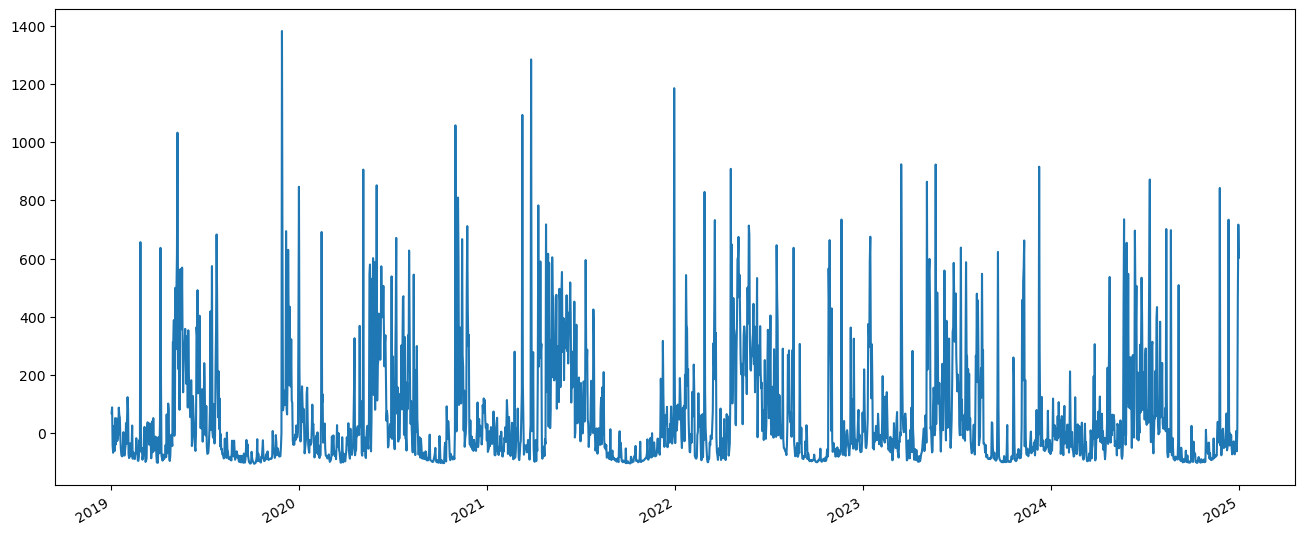

In [21]:
plt.figure(figsize=(16, 7))
print(historical_output)
historical_output.plot()

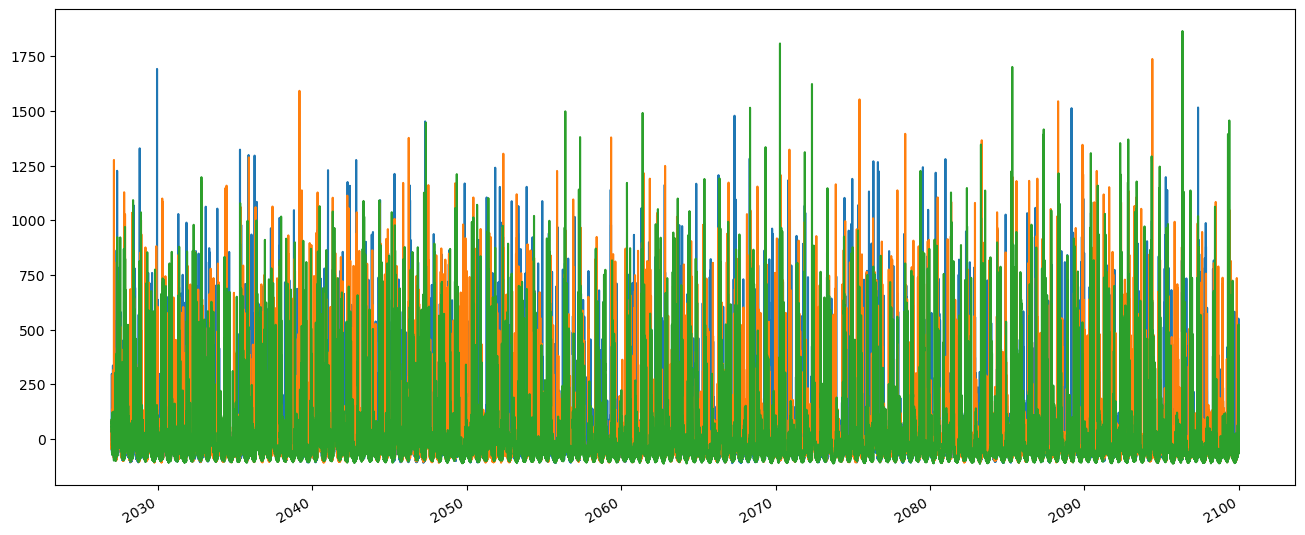

In [24]:
plt.figure(figsize=(16, 7))
SSP126_output.plot()
SSP245_output.plot()
SSP585_output.plot();